# Project 2

## Utils

In [47]:
import numpy as np
from math import sqrt, log
from scipy import stats
from joblib import Parallel, delayed
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
def f_lambda(a,b,t):
    return a*t**2 + b*t

def insert_into_sorted_list(sorted_list, new_tuple):
    """Inserts a tuple (e, t) into a list sorted in descending order
    based on the second element (t).
    """
    #print(new_tuple)
    new_t = new_tuple[2]
    
    # Iterate through the list to find the correct position
    for i, (_, _,current_t) in enumerate(sorted_list):
        if new_t >= current_t:
            sorted_list.insert(i, new_tuple)
            return sorted_list
            
    # If new_t is smaller than all existing elements,
    # append it to the end.
    sorted_list.append(new_tuple)
    return sorted_list

def first_index_le_zero(arr):
    """Returns the first index where the coordinate is <= 0.
    Returns None if no such coordinate exists.
    """
    # Find all indices where the condition is True
    indices = np.where(arr <= 0)[0]
    
    # If the resulting array is not empty, return the first index
    return indices[0] if indices.size > 0 else None

In [49]:
def sample_acceptance_exponential(f, lambda_max, t):
    Accepted = False
    x = np.random.exponential(scale = 1/lambda_max)
    acceptance_rate = f(x+t)/lambda_max
    u = np.random.uniform()
    if u < acceptance_rate :
        Accepted = True
    return Accepted, x

## Primary task : simulation

### Event based hospital class

In [50]:
class hostpital_EB :

    def __init__(self, a, b, LOS_Parameters, f_lambda, lambda_3, capacities, limit, LOS_distribution = 'LN'):
        self.t = 0 # current time

        self.a = a
        self.b = b

        self.lambda_3 = lambda_3
        self.f_lambda1 = lambda t : f_lambda(self.a,self.b,t)
        self.f_lambda2 = lambda t : f_lambda(self.a/5,self.b/5,t)
        self.lambda_max = self.f_lambda1(-self.b/(2*self.a))
        self.LOS = LOS_Parameters

        self.Capacities = np.array(capacities)
        self.limit = limit

        self.Wards = np.zeros(3) # nb of occupied bed per ward
        self.Ward_history = {i : [] for i in range(3)} # list of number of occupied beds per ward
        self.Flows = np.zeros((4,2)) # History of accepted/refused customers per ward
        self.PL = [] # Priority list

        self.LOS_distribution = LOS_distribution

    def sample_inter_arrival(self,w,t):
        if w == 0 :
            return sample_acceptance_exponential(self.f_lambda1, self.lambda_max, t)
        elif w ==1 : 
            return sample_acceptance_exponential(self.f_lambda2, self.lambda_max/5, t)
        elif w ==2 :
            return True, np.random.exponential(1/self.lambda_3)
        
    def reinitialize(self):
        self.PL = []
        self.t = 0
        self.Wards = np.zeros(3)
        self.Flows = np.zeros((3,2))
        self.Ward_history = {i : [] for i in range(3)}
    
    

######################## Schedule functions ###########################

    def schedule_free_bed(self,w, los_type=None):
        # los_type chooses WHICH length-of-stay distribution to sample from; it may
        # differ from the physical ward w.  A Ward-B (intensive) patient who overflows
        # into Ward A keeps the intensive 12-day stay -> los_type=1 while w=0.
        if los_type is None :
            los_type = w
        if self.LOS_distribution == "LN" :
            sojourn = np.random.lognormal(mean = self.LOS[los_type][0], sigma=self.LOS[los_type][1])
        elif self.LOS_distribution == "exp" :
            sojourn = np.random.exponential(scale = self.LOS[los_type])
        insert_into_sorted_list(self.PL,(("FB",w,self.t + sojourn)))

    def schedule_arrival(self,w,t,limit):
        is_accepted = False
        while (not is_accepted) and (t < limit) :
            is_accepted, x = self.sample_inter_arrival(w,t)
            t += x
        #print(f"Proposal x = {x} is accepted : {is_accepted} for ward w = {w}")
        if is_accepted :
            insert_into_sorted_list(self.PL,("Arr",w,t))

######################## Event functions ###########################

    def Free_bed(self,w):
        if self.Wards[w] > 0 :
            self.Wards[w] -= 1
            self.Ward_history[w].append((self.Wards[w],self.t)) # New bed available at time t in ward w

    def Arrive_ward(self,w,former_B = False):
        if self.Wards[w] < self.Capacities[w]: # If a bed is available in ward w
            self.Wards[w] += 1 # One more bed occupied
            if former_B :
                self.Flows[3][1] += 1 # special case of patient refused from ward B and accepted in A
            else :
                self.Flows[w][1] += 1 # A patient from ward w is accepted
            self.Ward_history[w].append((self.Wards[w],self.t)) # New occupied bed at time t in ward w
            #print(f"bed given at {self.t} in ward {w}")
            self.schedule_free_bed(w, los_type = (1 if former_B else w))  # overflow B keeps B's 12-day stay
        elif w == 1 and self.Wards[0] < self.Capacities[0]: # If the patient arrives at a full Ward B but space in Ward A
            self.Arrive_ward(0,former_B=True) # New patient arrives at Ward A
        else : # If no bed is available 
            self.Flows[w][0] += 1 # Patient refused at Ward w
        

###################### Main algorithm : Step_function ###############

    def initialize(self):
        for w in range(3):
            self.schedule_arrival(w,self.t, self.limit)

    def Step_function(self, limit):
        
        if self.t == 0 :
            self.initialize()
            
        Event_type, w, new_t = self.PL.pop() # returns last tuple of PL list
        #print(Event_type, w)

        if new_t < limit :
            self.t = new_t  # update time 
            if Event_type == "Arr" : 
                self.Arrive_ward(w)
                #print(self.Ward_history)
                self.schedule_arrival(w, self.t, self.limit)
            else :
                self.Free_bed(w)

        else :
            self.t = limit

    

### Tests

In [51]:
LOS = [(log(4*sqrt(2)),sqrt(log(2))), (log(6*sqrt(2)), sqrt(log(2))), (log(5*sqrt(2)), sqrt(log(2)))]
lambda_3 = 6

nb_A =  30   #30
nb_B =  20   #20
nb_C = 75 - nb_A - nb_B
Capacities = [nb_A,nb_B,nb_C]

limit = 365

a = -1/3650
b = 1/10

In [52]:
H = hostpital_EB(
    a = a,
    b = b,
    LOS_Parameters=LOS,
    f_lambda=f_lambda,
    lambda_3=lambda_3,
    capacities= Capacities,
    limit= limit 
)

#IA = H.sample_inter_arrival(0)
#print(IA, H.t)
limit = 365
epsilon = 0.01
#H.reinitialize()
iteration = 0
while H.t < limit - epsilon :
    if iteration % 100 == 0 :
        print(f"\niteration {iteration}, time : {H.t}")
    H.Step_function(limit)
    iteration += 1


iteration 0, time : 0

iteration 100, time : 11.61036353839053

iteration 200, time : 19.522169522767207

iteration 300, time : 26.685731607362033

iteration 400, time : 33.65642393728382

iteration 500, time : 41.34825182683032

iteration 600, time : 47.11374181835724

iteration 700, time : 53.213473706454046

iteration 800, time : 58.17119814260299

iteration 900, time : 63.70601145971594

iteration 1000, time : 68.56228130170275

iteration 1100, time : 73.07624777399026

iteration 1200, time : 77.71616818637673

iteration 1300, time : 82.46117383461831

iteration 1400, time : 87.6475116385021

iteration 1500, time : 92.88988583699906

iteration 1600, time : 97.05593239331895

iteration 1700, time : 102.11565392320139

iteration 1800, time : 106.66055452876671

iteration 1900, time : 111.75320633926923

iteration 2000, time : 116.58922710376658

iteration 2100, time : 120.56699421741156

iteration 2200, time : 124.98760871518363

iteration 2300, time : 129.25963875275633

iteration 

## Primary performances measures

In [53]:
mu = (H.a*(365**3)/3 + H.b*(365**2)/2)
print("mean of lambda(t) : ",mu/365)

mean of lambda(t) :  6.083333333333334


In [54]:
# --- Primary performance measures, averaged over N independent runs with 95% CIs ---
names = ["A", "B", "C"]
N_primary = 100   # number of independent simulated years

def run_once(capacities, LOS_dist="LN"):
    """Run one full 365-day simulation and return the finished hospital object."""
    H = hostpital_EB(a=a, b=b, LOS_Parameters=LOS, f_lambda=f_lambda,
                     lambda_3=lambda_3, capacities=capacities, limit=limit,
                     LOS_distribution=LOS_dist)
    while H.t < H.limit:
        H.Step_function(limit)
    return H

def primary_measures(H):
    """P(all beds full on arrival) and mean fraction of beds occupied, per ward."""
    F = H.Flows
    # A Ward-B patient sees Ward B full if it overflows into A (F[3][1]) OR is refused (F[1][0])
    p_full = [
        F[0][0] / (F[0][0] + F[0][1]),                                  # A
        (F[1][0] + F[3][1]) / (F[1][0] + F[1][1] + F[3][1]),            # B (includes overflow)
        F[2][0] / (F[2][0] + F[2][1]),                                  # C
    ]
    util = []
    for w in range(3):
        L = H.Ward_history[w]
        if len(L) == 0:                       # ward never occupied (e.g. 0 beds)
            util.append(0.0); continue
        occ = np.sum([(L[i][1]-L[i-1][1])*L[i-1][0] for i in range(1, len(L))]) / 365
        occ += (365 - L[-1][1]) * L[-1][0] / 365     # time-average number of occupied beds
        util.append(occ / H.Capacities[w])           # -> FRACTION of beds occupied
    return p_full, util

def mean_ci(x):
    """Mean and two-sided 95% t confidence interval of a sample."""
    x = np.asarray(x, dtype=float)
    m, s, n = x.mean(), x.std(ddof=1), len(x)
    h = stats.t.ppf(1 - 0.05/2, df=n-1) * s / sqrt(n)
    return m, m - h, m + h

P_full = np.zeros((N_primary, 3))
Util   = np.zeros((N_primary, 3))
for i in range(N_primary):
    H_i = run_once(Capacities, "LN")
    P_full[i], Util[i] = primary_measures(H_i)

print(f"Mean fraction of beds utilized over N = {N_primary} runs (95% CI):")
for w in range(3):
    m, lo, hi = mean_ci(Util[:, w])
    print(f"   Ward {names[w]} : {m:.4f}  [{lo:.4f}, {hi:.4f}]")


Mean fraction of beds utilized over N = 100 runs (95% CI):
   Ward A : 0.8523  [0.8504, 0.8542]
   Ward B : 0.6379  [0.6323, 0.6435]
   Ward C : 0.9671  [0.9666, 0.9676]


In [55]:
# Probability that all beds are occupied on arrival, per patient type (mean + 95% CI, same N runs)
print(f"P(all beds occupied on arrival) over N = {N_primary} runs (95% CI):")
for w in range(3):
    m, lo, hi = mean_ci(P_full[:, w])
    print(f"   Patient type {names[w]} : {m:.4f}  [{lo:.4f}, {hi:.4f}]")


P(all beds occupied on arrival) over N = 100 runs (95% CI):
   Patient type A : 0.4839  [0.4807, 0.4872]
   Patient type B : 0.1155  [0.1089, 0.1220]
   Patient type C : 0.5841  [0.5808, 0.5873]


In [56]:
def Relocated(nb_A,nb_B,nb_beds=75, limit = 365, LOS = LOS, f_lambda =  f_lambda, lambda_3 = lambda_3, mask = [1,1,1],a = -1/3650, b = 1/10, total = False, LOS_dist = "LN"):
    """Number of relocated people from wards chosen with the mask"""
    
    capacities = [nb_A,nb_B, nb_beds-nb_A-nb_B]
    H = hostpital_EB(
        a = a,
        b = b,
        LOS_Parameters=LOS,
        f_lambda=f_lambda,
        lambda_3=lambda_3,
        capacities= capacities,
        limit= limit,
        LOS_distribution= LOS_dist
        )
    while H.t < H.limit :
        H.Step_function(limit)
    if total :
        tot = 0
        for w in range(3):
            tot += mask[w]*np.sum(H.Flows[:3,:][w]) 
        tot += mask[1]*H.Flows[3][1]

        return np.sum([mask[w]*H.Flows[:3][w][0] for w in range(3)]), tot
    else :
        return np.sum([mask[w]*H.Flows[:3,:][w][0] for w in range(3)])

In [57]:
# Sanity check : Does the average obeserved number of patient per ward match the theory ?

Integral = (H.a*(365**3)/3 + H.b*(365**2)/2) # Integral of lambda(t)dt between 0 and 365
mu_total = np.array([Integral, 0.2*Integral, 6*365]) # Average number of people coming every year
var_total = mu_total.copy() # Variance of the total number of people coming every year
L = []
for i in range(100): 
    _,tot = Relocated(20,20,mask = [0,1,0], total = True)
    L.append(tot)
print(np.mean(L))
print(mu_total[1])

441.0
444.0833333333334


In [58]:
def Control_variate(nb_A,nb_B,nb_beds,N, mask = [1,1,1], original = False, LOS_dist = "LN"):
    """Number of relocated patients from wards chosen with the mask.

    This control variate version uses the total number of patient every year
    as the control variable"""

    R = np.zeros(N)
    Tot = np.zeros(N)
    for i in range(N):
        r,tot = Relocated(nb_A,nb_B,nb_beds,mask = mask,total=True, LOS_dist=LOS_dist)
        R[i] = r
        Tot[i] = tot
    c = np.cov(R,Tot)[0][1]/np.sum(var_total*mask)
    if original : 
        #print(np.shape(R),np.shape(Tot),np.shape(mu_total*mask))
        return R - c*(Tot-np.sum(mu_total*mask)), R
    else :
        return R - c*(Tot-np.sum(mu_total*mask))

In [59]:
N = 100
masks = [[1,0,0], [0,1,0], [0,0,1], [1,1,1]]
strings = ["Ward A", "Ward B", "Ward C", "all wards"]


for w in range(4):

    Y,R = Control_variate(nb_A=nb_A,nb_B=nb_B, nb_beds=75, N= N, mask=masks[w],original=True)
    R_bar = np.mean(R)
    s1 = np.std(R,ddof = 1)

    alpha = 0.05
    t = stats.t.ppf(1-0.05/2, df = N-1)
    ic_inf1 = R_bar - t*s1/sqrt(N)
    ic_sup1 = R_bar + t*s1/sqrt(N)
        

    print(f"Estimated number of relocated patients from  {strings[w]} without control variate : {R_bar:.2f},   IC = [{ic_inf1:.2f},{ic_sup1:.2f}]")

    Y_bar = np.mean(Y)
    s2 = np.std(Y,ddof = 1)

    alpha = 0.05
    t = stats.t.ppf(1-0.05/2, df = N-1)
    ic_inf2 = Y_bar - t*s2/sqrt(N)
    ic_sup2= Y_bar + t*s2/sqrt(N)
    

    print(f"Estimated number of relocated patients from  {strings[w]} with control variate:     {Y_bar:.2f},   IC = [{ic_inf2:.2f},{ic_sup2:.2f}]")
    print(f"Variance reduction : {100*(s1**2-s2**2)/(s1**2)} %")
    print(f"Std reduction : {100*(s1-s2)/(s1)} %")
    print("\n")

Estimated number of relocated patients from  Ward A without control variate : 1076.94,   IC = [1066.84,1087.04]
Estimated number of relocated patients from  Ward A with control variate:     1074.19,   IC = [1068.64,1079.73]
Variance reduction : 69.9123302699982 %
Std reduction : 45.14777148556149 %


Estimated number of relocated patients from  Ward B without control variate : 32.83,   IC = [30.79,34.87]
Estimated number of relocated patients from  Ward B with control variate:     32.59,   IC = [30.77,34.41]
Variance reduction : 20.24898932221056 %
Std reduction : 10.696578633408764 %


Estimated number of relocated patients from  Ward C without control variate : 1280.10,   IC = [1268.98,1291.22]
Estimated number of relocated patients from  Ward C with control variate:     1286.73,   IC = [1280.96,1292.50]
Variance reduction : 73.05280171446162 %
Std reduction : 48.08930911118754 %


Estimated number of relocated patients from  all wards without control variate : 2386.52,   IC = [2371.

In [60]:
# Sanity check
print(H.Flows)

[[1120. 1138.]
 [  34.  399.]
 [1268.  936.]
 [   0.   17.]]


# Sensitivity analysis

We organise the sensitivity analysis in three parts, in the same order as the
reference solution:

1. **Optimal bed distribution** of the 75 beds (the split minimising the total number of relocations).
2. **Sensitivity to the LOS distribution** &mdash; exponential vs lognormal stays (same means).
3. **Sensitivity to the total number of beds** &mdash; fewer and more than 75.

The optimisation method is unchanged: for every split `(a, b)` with `a + b < total`,
the mean total number of relocations is estimated with the **control-variate** estimator,
and we take the minimum over the full grid.

## 1. Optimal distribution of the 75 beds

In [ ]:
def _mean_relocations(a_, b_, nb_beds, N, LOS_dist):
    """Mean total relocations for the split (a_, b_) of nb_beds, via the control variate."""
    return np.mean(Control_variate(a_, b_, nb_beds, N, LOS_dist=LOS_dist))

def best_configuration(nb_beds, N=10, LOS_dist="LN"):
    """Optimisation (unchanged method): full grid over every split (a, b) with
    a + b < nb_beds, mean total relocations via the control-variate estimator,
    take the minimum over the grid."""
    points = [(a_, b_) for a_ in range(1, nb_beds) for b_ in range(1, nb_beds) if a_ + b_ < nb_beds]
    results = Parallel(n_jobs=-1)(
        delayed(_mean_relocations)(a_, b_, nb_beds, N, LOS_dist) for a_, b_ in points)
    minimum_val = min(results)
    best = points[results.index(minimum_val)]
    return best, minimum_val, points, results

def plot_landscape(nb_beds, points, results, minimum_val):
    """Heatmap of the optimisation landscape (darker = fewer relocations)."""
    M = np.full((nb_beds, nb_beds), np.nan)
    for (a_, b_), v in zip(points, results):
        M[b_, a_] = -np.log(abs(v - minimum_val) + 1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(M, cmap="viridis_r", cbar_kws={"label": "-log(|relocations - min| + 1)"})
    plt.title(f"Optimisation landscape, {nb_beds} beds  (darker = fewer relocations)")
    plt.xlabel("Ward A beds (a)"); plt.ylabel("Ward B beds (b)")
    plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

Optimal split of the 75 beds: A = 32, B = 2, C = 41
   estimated total relocated patients / year = 2106


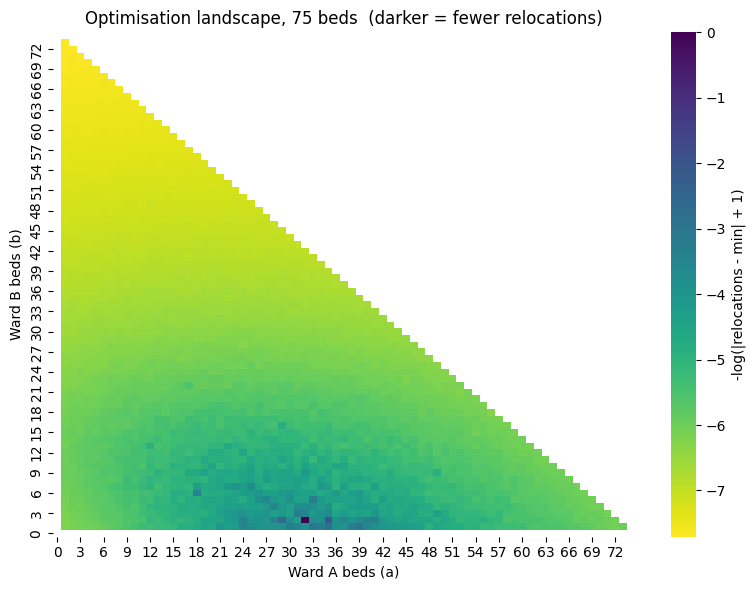

In [66]:
N_opt = 10   # repetitions per grid point (unchanged from his approach)

best75, min75, pts75, res75 = best_configuration(75, N=N_opt)
a75, b75 = best75
c75 = 75 - a75 - b75
print(f"Optimal split of the 75 beds: A = {a75}, B = {b75}, C = {c75}")
print(f"   estimated total relocated patients / year = {min75:.0f}")
plot_landscape(75, pts75, res75, min75)

## 2. Sensitivity to the LOS distribution (exponential vs lognormal)

We test how the performance measures respond when the length-of-stay distribution
is changed from lognormal to **exponential** with the **same means** (8 / 12 / 10 days).
Both distributions have mean = standard deviation (CV = 1), so the comparison isolates
the effect of the distribution *shape*.  The comparison is done at the baseline bed
split (the one used for the primary measures), and each measure is averaged over `N`
runs with a 95% confidence interval.

In [63]:
LOS_LN  = [(log(4*sqrt(2)), sqrt(log(2))), (log(6*sqrt(2)), sqrt(log(2))), (log(5*sqrt(2)), sqrt(log(2)))]
LOS_EXP = [8, 12, 10]
cap_los = list(Capacities)        # baseline split, same as the primary measures
N_los = 100

def los_measures(capacities, los_params, los_dist, N):
    """Per-run P(full), utilisation fraction and relocations for wards A, B, C."""
    Pf = np.zeros((N, 3)); Ut = np.zeros((N, 3)); Rl = np.zeros((N, 3))
    for i in range(N):
        H = hostpital_EB(a=a, b=b, LOS_Parameters=los_params, f_lambda=f_lambda,
                         lambda_3=lambda_3, capacities=capacities, limit=limit,
                         LOS_distribution=los_dist)
        while H.t < H.limit:
            H.Step_function(limit)
        Pf[i], Ut[i] = primary_measures(H)
        Rl[i] = [H.Flows[0][0], H.Flows[1][0], H.Flows[2][0]]
    return Pf, Ut, Rl

Pf_ln, Ut_ln, Rl_ln = los_measures(cap_los, LOS_LN, "LN", N_los)
Pf_ex, Ut_ex, Rl_ex = los_measures(cap_los, LOS_EXP, "exp", N_los)

wards = ["A", "B", "C"]
print(f"LOS sensitivity at split A={cap_los[0]} B={cap_los[1]} C={cap_los[2]}, {N_los} runs (95% CI)")
print(f"{'measure':<14}{'lognormal':>24}{'exponential':>24}")
def _row(label, ln_col, ex_col, fmt):
    lm, ll, lh = mean_ci(ln_col); em, el, eh = mean_ci(ex_col)
    c = lambda m, lo, hi: f"{fmt.format(m)} [{fmt.format(lo)},{fmt.format(hi)}]"
    print(f"{label:<14}{c(lm, ll, lh):>24}{c(em, el, eh):>24}")
for w in range(3):
    _row(f"P(full) {wards[w]}", Pf_ln[:, w], Pf_ex[:, w], "{:.4f}")
for w in range(3):
    _row(f"reloc {wards[w]}", Rl_ln[:, w], Rl_ex[:, w], "{:.0f}")
for w in range(3):
    _row(f"util {wards[w]}", Ut_ln[:, w], Ut_ex[:, w], "{:.3f}")
_row("TOTAL reloc", Rl_ln.sum(1), Rl_ex.sum(1), "{:.0f}")

LOS sensitivity at split A=30 B=20 C=25, 100 runs (95% CI)
measure                      lognormal             exponential
P(full) A       0.4822 [0.4791,0.4852]  0.4833 [0.4801,0.4866]
P(full) B       0.1156 [0.1089,0.1223]  0.1156 [0.1095,0.1217]
P(full) C       0.5852 [0.5823,0.5882]  0.5846 [0.5813,0.5878]
reloc A               1073 [1064,1083]        1070 [1059,1080]
reloc B                     32 [30,34]              33 [31,35]
reloc C               1283 [1272,1293]        1283 [1272,1294]
util A             0.853 [0.851,0.856]     0.852 [0.850,0.855]
util B             0.638 [0.632,0.644]     0.637 [0.631,0.643]
util C             0.968 [0.967,0.968]     0.967 [0.966,0.968]
TOTAL reloc           2388 [2374,2402]        2386 [2371,2400]


## 3. Sensitivity to the total number of beds

Using the **same optimisation method**, we re-find the best split for several total
numbers of beds (fewer and more than 75) and report the resulting minimum total
number of relocations.

In [64]:
print(f"{'total beds':>10}{'optimal split':>20}{'min total relocated':>22}")
for total in [30, 50, 80, 100]:
    best, mn, _, _ = best_configuration(total, N=N_opt)
    print(f"{total:>10}     A={best[0]:2d} B={best[1]:2d} C={total-best[0]-best[1]:2d}{mn:>16.0f}")

total beds       optimal split   min total relocated
        30     A= 9 B= 1 C=20            3686
        50     A=24 B= 0 C=26            2944
        80     A=33 B= 0 C=47            1941
       100     A=47 B= 0 C=53            1336
